# Recourse

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging
from itertools import combinations

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)
from monoculture.baseline.utils import load_baselines
from monoculture.analysis.metrics import get_fraction_no_recourse, poisson_binom_agreement, get_ambiguity, get_discrepancy

In [82]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"

ERROR:root:A task with `name='ACSIncome'` already exists. Overwriting...
ERROR:root:A task with `name='ACSPublicCoverage'` already exists. Overwriting...
ERROR:root:A task with `name='ACSMobility'` already exists. Overwriting...
ERROR:root:A task with `name='ACSEmployment'` already exists. Overwriting...
ERROR:root:A task with `name='ACSTravelTime'` already exists. Overwriting...
ERROR:root:A task with `name='ACSIncomePovertyRatio'` already exists. Overwriting...
ERROR:root:A task with `name='ACSHealthInsurance-test'` already exists. Overwriting...
ERROR:root:A task with `name='BRFSS_Diabetes'` already exists. Overwriting...
ERROR:root:A task with `name='BRFSS_Blood_Pressure'` already exists. Overwriting...


tasks ('ACSIncome', 'ACSEmployment', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Blood_Pressure')


In [4]:
data = None

## Load predictions

In [74]:
num_shots = 10
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
97,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.561753,0.656335,3470739438,10,bullet,is,original,default,results/folktexts/10-reuse-bullet-is/model-met...,results/folktexts/10-reuse-bullet-is/model-met...
99,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.515625,0.749012,2324583217,10,bullet,is,original,default,results/folktexts/10-reuse-bullet-is/model-all...,results/folktexts/10-reuse-bullet-is/model-all...
100,ACSIncome,google--gemma-2-27b,0,1,0.222857,0.439928,1131097222,10,bullet,is,original,default,results/folktexts/10-reuse-bullet-is/model-goo...,results/folktexts/10-reuse-bullet-is/model-goo...
103,ACSIncome,google--gemma-2-27b-it,1,1,0.561828,0.562487,4205512169,10,bullet,is,original,default,results/folktexts/10-reuse-bullet-is/model-goo...,results/folktexts/10-reuse-bullet-is/model-goo...
104,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.437500,0.770183,3438939263,10,bullet,is,original,default,results/folktexts/10-reuse-bullet-is/model-met...,results/folktexts/10-reuse-bullet-is/model-met...


In [75]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(set(df_same_prompt["task"].unique()).intersection(TASKS))
TASKS

(194, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Blood_Pressure')

In [76]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_54709/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_54709/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_54709/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

## Restrict analysis to models based on performance or true labels?

In [109]:
restrict_to_better_const = False
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

restrict_to_model_family = False  #'Llama'  # name of family
restrict_to_base_models = False
restrict_to_it_models = False
assert not (restrict_to_base_models and restrict_to_it_models), "Choose one or none."

restrict_to_top_eps = False #True
restrict_to_topk = False
topk = 10
eps = 0.05

predictions = predictions_all.copy()

if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in sorted(TASKS):
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)
            # df_same_prompt[df_same_prompt["task"] == task] = df_same_prompt[df_same_prompt["task"] == task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)

if restrict_to_topk or restrict_to_top_eps:
    assert not (restrict_to_top_eps and restrict_to_topk)
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
            # df_same_prompt[df_same_prompt["task"] == task] =df_same_prompt[df_same_prompt["task"] == task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
            df_same_prompt[df_same_prompt["task"] == task] = df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]
        print(task, predictions[task].shape)

if restrict_to_model_family:
    print(f"Restrict to model family {restrict_to_model_family}")
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (restrict_to_model_family in row.model),
                    axis=1,
                )
            ]["model"].unique()
        )
        print(len(models_filtered))
        predictions[task] = predictions[task].filter(items=models_filtered)
        # df_same_prompt[df_same_prompt["task"] == task] = df_same_prompt[df_same_prompt["task"] == task].filter(items=models_filtered)
        print(task, predictions[task].shape)

if any([restrict_to_base_models, restrict_to_it_models]):
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (row.is_inst == int(restrict_to_it_models)),
                    axis=1,
                )
            ]["model"].unique()
        )
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

ACSEmployment (146740, 48)
ACSIncome (61233, 48)
ACSPublicCoverage (33971, 35)
ACSTravelTime (64285, 22)
BRFSS_Blood_Pressure (44586, 41)


## Systemic Failure (No Recourse) as a function of the Rashomon Set Size

In [112]:
no_recourse = {}
epsilon_per_task = {}
multiplicity_measures = {}


for task in sorted(TASKS):
    no_recourse[task] = {}
    multiplicity_measures[task] = {}

    df_task_sorted_by_acc = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
    )
    top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
    max_eps = 0.05
    y_true = data[task][1]
    const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
    print(f"{task} top: {top_acc:.4f} const: {const_acc:.4f} diff: {top_acc - const_acc:0.4f}")
    
    
    # epsilon = np.arange(0, top_acc - const_acc+0.005, 0.005)
    epsilon = np.arange(0,max_eps+0.005, 0.005)
    epsilon_per_task[task] = epsilon

    no_recourse_observed = []
    no_recourse_at_random = []
    num_models = []
    ambiguities = []
    discrepancies = []

    for eps in epsilon:
        mask = (df_task_sorted_by_acc["accuracy"] >= top_acc - eps)
        if restrict_to_better_const:
            mask &= (df_task_sorted_by_acc["accuracy"] >= const_acc)
        models = sorted(
            df_task_sorted_by_acc[mask][
                "model"
            ].to_list(),
            key=get_size_and_it,
        )

        tp_rates = [1. - evals_per_task_all[task]['fnr'][model] for model in models]
        filtered_df = predictions[task].filter(items=models)

        if len(models) > 0 and predictions[task].shape[1] > 0:
            no_recourse_observed.append(
                get_fraction_no_recourse(
                    predictions[task].filter(items=models).to_numpy()
                )
            )
            no_recourse_at_random.append(poisson_binom_agreement(baseline_rate=tp_rates, k=0))
            num_models.append(len(models))
            ambiguities.append(get_ambiguity(filtered_df))
            discrepancies.append(get_discrepancy(filtered_df))

    if predictions[task].shape[1] > 0:
        no_recourse[task] = {
            "eps": epsilon,
            "$|\mathcal{R_\epsilon}|$": num_models,
            "observed": no_recourse_observed,
            "random_error": no_recourse_at_random,
        }
        multiplicity_measures[task] = {
            "eps": epsilon,
            "$|\mathcal{R_\epsilon}|$": num_models,
            "ambiguity": np.array(ambiguities),
            "discrepancy": np.array(discrepancies),
        }
    print(task, no_recourse[task])

ACSEmployment top: 0.8097 const: 0.5466 diff: 0.2631
ACSEmployment {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), '$|\\mathcal{R_\\epsilon}|$': [1, 1, 3, 5, 5, 5, 5, 6, 6, 9, 12], 'observed': [0.1774499114079324, 0.1774499114079324, 0.12999182227068284, 0.11416110126754804, 0.11416110126754804, 0.11416110126754804, 0.11416110126754804, 0.10778247240016356, 0.10778247240016356, 0.08068692926264141, 0.07274771705056562], 'random_error': [0.17744991140793243, 0.17744991140793243, 0.005729015170735918, 0.00019114767329103443, 0.00019114767329103443, 0.00019114767329103443, 0.00019114767329103443, 4.376309957670433e-05, 4.376309957670433e-05, 1.7970299374347947e-07, 7.822387141856203e-10]}
ACSIncome top: 0.7905 const: 0.6321 diff: 0.1584
ACSIncome {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), '$|\\mathcal{R_\\epsilon}|$': [1, 3, 5, 9, 10, 15, 20, 22, 23, 28, 31], 'observed': [0.28520

no-recourse-multiplicity-10-shot_tresh_fitted_pos_instances


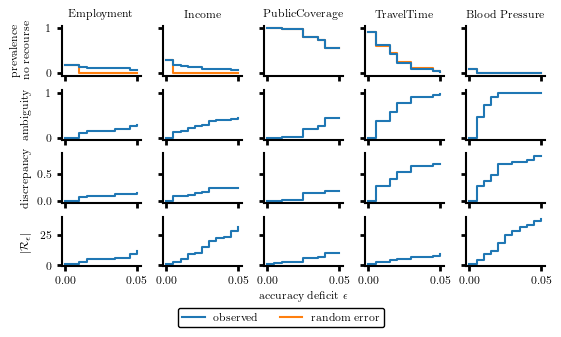

In [ ]:
tasks_to_plot = ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure'] #sorted(TASKS) #

fig, axs = plt.subplots(
    4,
    len(tasks_to_plot),
    constrained_layout=True,
    sharey="row",
    sharex=True
)

for m, measure in enumerate(["no_recourse", "ambiguity", "discrepancy", "$|\mathcal{R_\epsilon}|$"]):
    for t, task in enumerate(tasks_to_plot):
        if len(no_recourse[task]) > 0:
            if m == 0:
                axs[m, t].step(
                    no_recourse[task]["eps"],
                    no_recourse[task]["random_error"],
                    where="post",
                    color="C1",
                    label="random error",
                )
                axs[m, t].step(
                    no_recourse[task]["eps"],
                    no_recourse[task]["observed"],
                    where="post",
                    color="C0",
                    label="observed",
                )
            else:
                axs[m, t].step(
                    multiplicity_measures[task]["eps"],
                    multiplicity_measures[task][measure],
                    color="C0",
                    where="post",
                )
                # axs[m, t].scatter(
                #     multiplicity_measures[task]["eps"],
                #     multiplicity_measures[task][measure],
                #     color="C0",
                # )
        else:
            axs[m, t].set_axis_off()
        axs[0,t].set_title(task.replace("ACS", "").replace("BRFSS", "").replace("_", " "))
    if m==0:
        axs[0,0].set_ylabel("prevalence\n no recourse")
    else:
        axs[m,0].set_ylabel(measure)
# axs[0].legend()
axs[-1,len(tasks_to_plot) // 2].set_xlabel(r"accuracy deficit $\epsilon$")
# xticks = np.linspace(no_recourse[task]["eps"].min(), no_recourse[task]["eps"].max(), num=3)
# axs[0,0].set_xticks(xticks, [f"{tick:.2}" for tick in xticks])

fig.align_ylabels(axs[:, 0])
# legend
# legend
desired_order = ['observed', 'random error', 'random prediction', 'monoculture']
handles, labels = axs[0,0].get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
ordered_labels = [label for label in desired_order if label in unique]
ordered_handles = [unique[label] for label in ordered_labels]
# positioning
# get the bottom-most y-position among all axes
lowest_ax_y = min([ax.get_position().y0 for ax in axs.flat])

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, lowest_ax_y-0.2),
    frameon=True,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)
# plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 1.0))

file_name = "".join(
    [
        f"no-recourse-multiplicity-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

In [114]:
no_recourse['ACSPublicCoverage']

{'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
        0.045, 0.05 ]),
 '$|\\mathcal{R_\\epsilon}|$': [1, 2, 3, 3, 3, 6, 6, 7, 10, 10, 10],
 'observed': [1.0,
  0.9948779841629626,
  0.972152718495187,
  0.972152718495187,
  0.972152718495187,
  0.7935003385240352,
  0.7935003385240352,
  0.733596302728798,
  0.5487327426334226,
  0.5487327426334226,
  0.5487327426334226],
 'random_error': [1.0,
  0.9948779841629626,
  0.9721519732798429,
  0.9721519732798429,
  0.9721519732798429,
  0.7978423203960054,
  0.7978423203960054,
  0.7297094844044594,
  0.5585423275518825,
  0.5585423275518825,
  0.5585423275518825]}

In [80]:
m = no_recourse[task][r"cardinality $|\mathcal{R}|$"][np.where(no_recourse[task]['eps']==0.01)[0][0]]
df_same_prompt[df_same_prompt['task']=='ACSIncome'].sort_values(by='accuracy', ascending=False).iloc[:m]

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,prompt_feature_order,eval_results_path,predictions_path,n_samples,fpr,fnr,ppr,num_pred_negatives,num_pred_positives,balanced_accuracy
178,ACSIncome,mistralai--Mixtral-8x22B-Instruct-v0.1,1,1,0.730469,0.790526,768230323,10,bullet,is,...,default,results/folktexts/10-reuse-bullet-is/model-mis...,results/folktexts/10-reuse-bullet-is/model-mis...,166450,0.165401,0.285206,0.367510,105278,61172,0.774697
166,ACSIncome,Qwen--Qwen2-72B,0,1,0.562500,0.787167,2452061313,10,bullet,is,...,default,results/folktexts/10-reuse-bullet-is/model-Qwe...,results/folktexts/10-reuse-bullet-is/model-Qwe...,166450,0.208236,0.220731,0.418306,96823,69627,0.785517
106,ACSIncome,mistralai--Mistral-Small-24B-Base-2501,0,1,0.468750,0.785539,1414488504,10,bullet,is,...,default,results/folktexts/10-reuse-bullet-is/model-mis...,results/folktexts/10-reuse-bullet-is/model-mis...,166450,0.209757,0.222543,0.418600,96774,69676,0.783850


In [81]:
# latex table
print(eps)
print(f"{'task':20}& M &{'ambiguity':14}&{'discrepancy':20}\\\\" )
for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
         )
        top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
        models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
        tmp_filtered_preds = predictions[task].filter(items=models)  
        print(f"{task:20}&{tmp_filtered_preds.shape[1]}& {get_ambiguity(tmp_filtered_preds):.3f}&{get_discrepancy(tmp_filtered_preds):.3f}\\\\" )

0.05
task                & M &ambiguity     &discrepancy         \\
ACSIncome           &31& 0.437&0.246\\
ACSEmployment       &12& 0.284&0.144\\
ACSTravelTime       &0& 0.000&0.000\\
ACSPublicCoverage   &0& 0.000&0.000\\
BRFSS_Blood_Pressure&3& 0.371&0.288\\
